# BPE-токенизация

Обучение и сравнение пяти генеративных моделей (Simple RNN, LSTM 1-слойная, LSTM 3-слойная, двунаправленная LSTM, MiniGPT) с использованием **BPE-токенизации** на датасете Medium Articles.

In [1]:
import torch
import os
import sys
import tempfile

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '.')) if os.path.exists('utils.py') else os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utils import load_medium_articles, TextDataset, make_dataloaders, train_model, compute_perplexity, generate_text, plot_training_curves, print_generation_samples
from models import build_all_models, count_parameters

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')

Устройство: cuda
GPU: NVIDIA GeForce RTX 4060 Ti

## 1. Загрузка датасета

In [2]:
corpus = load_medium_articles('data/medium_articles.csv', max_articles=5000)
print(f'Пример: {corpus[:300]}')

Загружено 5000 статей, длина корпуса: 28,081,679 символов
Пример: Photo by Josh Riemer on Unsplash

Merry Christmas and Happy Holidays, everyone!

We just wanted everyone to know how much we appreciate everyone and how thankful we are for all our readers and writers here. We wouldn't be anywhere without you, so thank you all for bringing informative, vulnerable, a

## 2. Обучение BPE-токенизатора

In [3]:
from tokenizers import Tokenizer, models as tok_models, trainers, pre_tokenizers, decoders

# Запись корпуса во временный файл для обучения токенизатора
CORPUS_TMP = os.path.join(tempfile.gettempdir(), 'medium_corpus_bpe.txt')
with open(CORPUS_TMP, 'w', encoding='utf-8') as f:
    f.write(corpus)
print(f'Корпус сохранён: {CORPUS_TMP}')

Корпус сохранён во временный файл для обучения BPE

In [4]:
VOCAB_SIZE = 16000

tokenizer_bpe = Tokenizer(tok_models.BPE(unk_token='<UNK>'))
tokenizer_bpe.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
tokenizer_bpe.decoder = decoders.ByteLevel()

trainer = trainers.BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=['<PAD>', '<UNK>'],
    min_frequency=2,
    show_progress=True,
)

tokenizer_bpe.train([CORPUS_TMP], trainer)
print(f'Размер словаря BPE: {tokenizer_bpe.get_vocab_size()}')

Размер словаря BPE: 16000

In [5]:
# Сохранение обученного токенизатора
os.makedirs('tokenizers', exist_ok=True)
tokenizer_bpe.save('tokenizers/bpe_medium.json')
print('BPE-токенизатор сохранён: tokenizers/bpe_medium.json')

BPE-токенизатор сохранён: tokenizers/bpe_medium.json

In [6]:
class BPETokenizerWrapper:
    """Обёртка над HuggingFace Tokenizer для совместимости с нашим API."""

    def __init__(self, hf_tokenizer):
        self.tok = hf_tokenizer
        self.vocab_size = hf_tokenizer.get_vocab_size()

    def encode(self, text):
        return self.tok.encode(text).ids

    def decode(self, ids):
        return self.tok.decode(ids)


tokenizer = BPETokenizerWrapper(tokenizer_bpe)

# Проверка
sample = 'The future of artificial intelligence is bright.'
encoded = tokenizer.encode(sample)
decoded = tokenizer.decode(encoded)
print(f'Оригинал:  {sample}')
print(f'Токены:    {encoded[:20]} ... ({len(encoded)} токенов)')
print(f'Декодировано: {decoded}')
print(f'Размер словаря: {tokenizer.vocab_size}')

Оригинал:  The future of artificial intelligence is bright.
Токены:    [416, 1368, 233, 3790, 2654, 256, 6736, 15] ... (8 токенов)
Декодировано: The future of artificial intelligence is bright.
Размер словаря: 16000

In [7]:
# Кодирование корпуса
token_ids = tokenizer.encode(corpus)
print(f'Всего токенов: {len(token_ids):,}')
print(f'Степень сжатия: {len(corpus)/len(token_ids):.2f} символов/токен')

Всего токенов: 6,695,040
Степень сжатия: 4.19 символов/токен

## 3. Создание DataLoader'ов

In [8]:
SEQ_LEN = 64
BATCH_SIZE = 256

train_dl, val_dl = make_dataloaders(token_ids, SEQ_LEN, BATCH_SIZE, val_split=0.1)
print(f'Батчей на эпоху — train: {len(train_dl)}, val: {len(val_dl)}')

Последовательностей — train: 94148, val: 10460
Батчей на эпоху — train: 367, val: 40

## 4. Построение моделей

In [9]:
EMBED_DIM = 256
HIDDEN_DIM = 512
GPT_DIM = 256
GPT_HEADS = 4
GPT_LAYERS = 4
GPT_FF = 512

models = build_all_models(
    vocab_size=tokenizer.vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    gpt_dim=GPT_DIM,
    gpt_heads=GPT_HEADS,
    gpt_layers=GPT_LAYERS,
    gpt_ff=GPT_FF,
    max_seq_len=SEQ_LEN,
)

for name, model in models.items():
    print(f'{name}: {count_parameters(model):,} параметров')

SimpleRNN: 12,698,240 параметров
LSTM_1layer: 13,880,960 параметров
LSTM_3layer: 18,083,456 параметров
BiLSTM: 29,949,568 параметров
MiniGPT: 6,221,312 параметров

## 4б. Загрузка сохранённых чекпойнтов (пропуск обучения)

In [10]:
# Загрузка чекпойнтов вместо повторного обучения.
# Ячейки 1-4 выше должны быть выполнены (токенизатор + модели).

SAVE_DIR = 'checkpoints/bpe'
loaded = []
for name, model in models.items():
    ckpt = os.path.join(SAVE_DIR, f'bpe_{name}_best.pt')
    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        loaded.append(name)
        print(f'Загружена {name} из {ckpt}')
    else:
        print(f'ВНИМАНИЕ: чекпойнт не найден для {name} по пути {ckpt}')

print(f'\nЗагружено моделей: {len(loaded)}/{len(models)}')

Загружена SimpleRNN из checkpoints/bpe/bpe_SimpleRNN_best.pt
Загружена LSTM_1layer из checkpoints/bpe/bpe_LSTM_1layer_best.pt
Загружена LSTM_3layer из checkpoints/bpe/bpe_LSTM_3layer_best.pt
Загружена BiLSTM из checkpoints/bpe/bpe_BiLSTM_best.pt
Загружена MiniGPT из checkpoints/bpe/bpe_MiniGPT_best.pt

Загружено моделей: 5/5

## 5. Обучение всех моделей

In [11]:
EPOCHS = 15
PATIENCE = 5
SAVE_DIR = 'checkpoints/bpe'

histories = {}

training_config = {
    'SimpleRNN':   {'lr': 1e-3, 'use_amp': False},
    'LSTM_1layer': {'lr': 1e-3, 'use_amp': False},
    'LSTM_3layer': {'lr': 1e-3, 'use_amp': False},
    'BiLSTM':      {'lr': 1e-3, 'use_amp': False},
    'MiniGPT':     {'lr': 3e-4, 'use_amp': True},
}

In [12]:
for name, model in models.items():
    print(f'\nОбучение {name}')
    print('-' * 40)
    cfg = training_config[name]
    histories[name] = train_model(
        model, train_dl, val_dl,
        epochs=EPOCHS,
        lr=cfg['lr'],
        device=DEVICE,
        use_amp=cfg['use_amp'],
        patience=PATIENCE,
        model_name=f'bpe_{name}',
        save_dir=SAVE_DIR,
    )

Обучение SimpleRNN
----------------------------------------
  [bpe_SimpleRNN] Epoch 1: train_loss=6.2181  val_loss=5.7426  val_ppl=311.89
  [bpe_SimpleRNN] Epoch 2: train_loss=5.3847  val_loss=5.3868  val_ppl=218.51
  [bpe_SimpleRNN] Epoch 3: train_loss=5.0907  val_loss=5.2302  val_ppl=186.84
  [bpe_SimpleRNN] Epoch 4: train_loss=4.9266  val_loss=5.1503  val_ppl=172.49
  [bpe_SimpleRNN] Epoch 5: train_loss=4.8174  val_loss=5.0958  val_ppl=163.34
  [bpe_SimpleRNN] Epoch 6: train_loss=4.7356  val_loss=5.0659  val_ppl=158.53
  [bpe_SimpleRNN] Epoch 7: train_loss=4.6706  val_loss=5.0445  val_ppl=155.16
  [bpe_SimpleRNN] Epoch 8: train_loss=4.6180  val_loss=5.0294  val_ppl=152.84
  [bpe_SimpleRNN] Epoch 9: train_loss=4.5734  val_loss=5.0237  val_ppl=151.98
  [bpe_SimpleRNN] Epoch 10: train_loss=4.5350  val_loss=5.0060  val_ppl=149.31
  [bpe_SimpleRNN] Epoch 11: train_loss=4.5015  val_loss=5.0018  val_ppl=148.68
  [bpe_SimpleRNN] Epoch 12: train_loss=4.4696  val_loss=4.9960  val_ppl=147.82
 

## 6. Кривые обучения

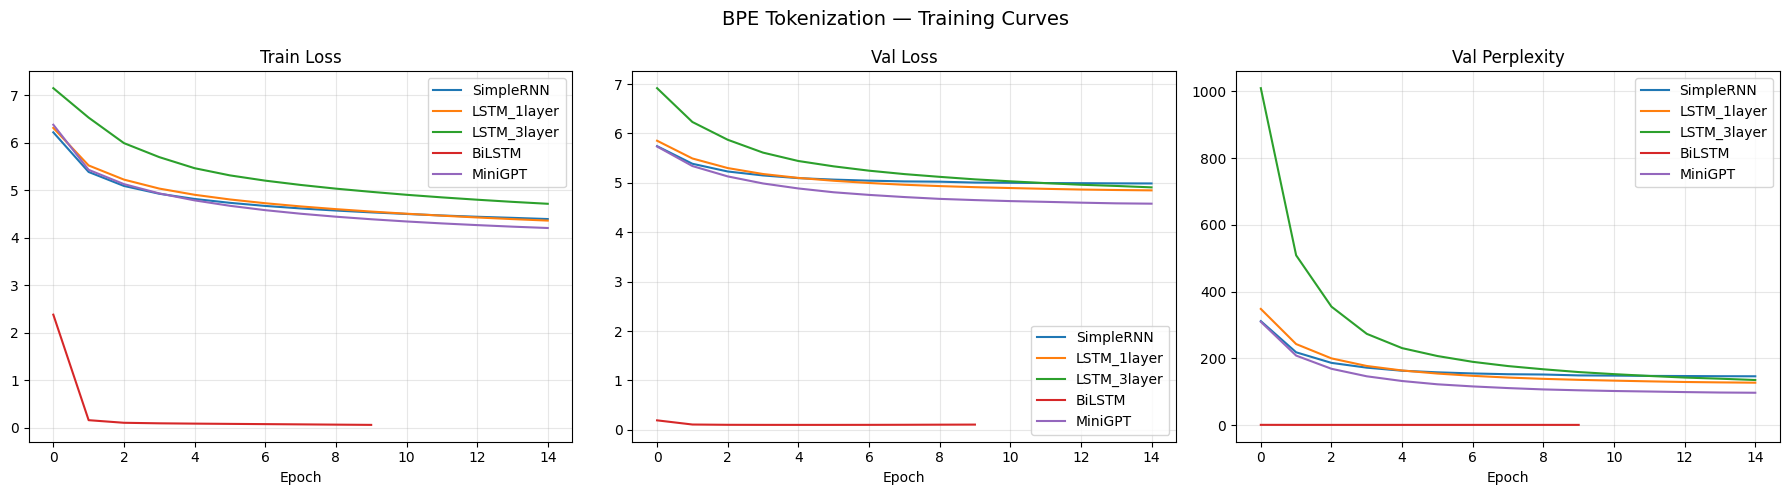

In [13]:
plot_training_curves(histories, title='BPE Tokenization — Training Curves')

## 7. Итоговое сравнение перплексии

In [14]:
print(f'{"Модель":<20} {"Перплексия":<15} {"Параметры":<15}')
print('-' * 50)
for name, model in models.items():
    ppl = compute_perplexity(model, val_dl, device=DEVICE, use_amp=('GPT' in name))
    params = count_parameters(model)
    print(f'{name:<20} {ppl:<15.2f} {params:<15,}')

Модель               Перплексия      Параметры
--------------------------------------------------
SimpleRNN            146.65          12,698,240
LSTM_1layer          127.49          13,880,960
LSTM_3layer          135.50          18,083,456
BiLSTM               1.10            29,949,568
MiniGPT              97.36           6,221,312

## 8. Примеры генерации текста

In [15]:
seed_text = 'The future of artificial intelligence '
seed_ids = tokenizer.encode(seed_text)
print(f'Сид: "{seed_text}"')
print(f'Количество токенов: {len(seed_ids)}')
print(f'ID токенов: {seed_ids}')

Сид: "The future of artificial intelligence "
Количество токенов: 6
ID токенов: [416, 1368, 233, 3790, 2654, 162]

In [16]:
samples = {}
for name, model in models.items():
    samples[name] = generate_text(
        model, seed_ids, tokenizer.decode,
        length=100, temperature=0.8, top_k=50,
        device=DEVICE, max_context=SEQ_LEN,
    )

print_generation_samples(samples, title='Примеры генерации (BPE-токенизация)')

Примеры генерации (BPE-токенизация)

--- SimpleRNN ---
The future of artificial intelligence ib in this way is to identify the outcome from the perspective in general public.

Influence, the cost of renewable energy sources increases efficiency is the result in a single time of a new business card. It also makes it easier to maintain their own functions.

I'm a firm believer and the time, that are needed to help you identify.

We are not doing the right thing to be as if we could do it with others.

The first thing

--- LSTM_1layer ---
The future of artificial intelligence urns — can be leveraged, and it's hard to develop a better understanding of AI.

For example, if it is not an easy way to know what the world is, is it the possible outcome of the time for we've never seen in the future.

The challenge is the one thing that is about the problem we could do about ourselves. The same goes this: I'm not a good place to share my health, but it's very important to add

--- LSTM_3layer ---

## 9. Генерация при различных температурах

In [17]:
# Влияние температуры на лучшую модель (MiniGPT)
best_model = models['MiniGPT']
for temp in [0.3, 0.5, 0.8, 1.0, 1.2]:
    text = generate_text(
        best_model, seed_ids, tokenizer.decode,
        length=80, temperature=temp, top_k=50,
        device=DEVICE, max_context=SEQ_LEN,
    )
    print(f'\n--- Температура = {temp} ---')
    print(text[:400])

--- Температура = 0.3 ---
The future of artificial intelligence between the model and the first time is the first time to access the first time.

As a simple as a matrix of the internet processes in the case of the world. The program was a series of the problems w

--- Температура = 0.5 ---
The future of artificial intelligence is pretty more than the company of the two simplest options and a container that is the most product of the training responses to the output of our strengths to a high quality from our service.

As we

--- Температура = 0.8 ---
The future of artificial intelligence between 10 to 100 and 60% of users and square are of this.

The data correctly for a single brand button for a local traffic command: we must have to use the performance of the platform and horrible f

--- Температура = 1.0 ---
The future of artificial intelligence is repeatedly producted to the experience.

One side, it is represented the survivor of that far delicious and definitely profile to enabl

## 10. Итоги

| Модель | Val Loss | Val Perplexity | Параметры |
|--------|----------|----------------|-----------|
| SimpleRNN | 4.988 | 146.65 | 12 698 240 |
| LSTM (1 слой) | 4.849 | 127.49 | 13 880 960 |
| LSTM (3 слоя) | 4.909 | 135.50 | 18 083 456 |
| Bidirectional LSTM | 0.095 | 1.10 | 29 949 568 |
| MiniGPT | 4.578 | 97.36 | 6 221 312 |

**Лучшая модель по перплексии:** MiniGPT (97.36) — среди однонаправленных моделей, пригодных для генерации.

> **Примечание:** BiLSTM показывает аномально низкую перплексию (~1.10), так как двунаправленная архитектура «видит» будущие токены. Это делает её непригодной для авторегрессионной генерации, но формально она минимизирует loss лучше всех.